# Bayesian A/B Testing

## Overview

Bayesian A/B testing answers the questions practitioners actually want to ask: "What is the probability that B is better than A?" and "What is the expected loss from choosing the wrong variant?" Frequentist tests answer neither — they only assess compatibility with the null hypothesis.

**Frequentist vs. Bayesian A/B test:**

| Question | Frequentist | Bayesian |
|---|---|---|
| Is there an effect? | p < α → reject H₀ | P(B > A \| data) |
| How big is it? | Point estimate + CI | Posterior distribution |
| Can I stop early? | No (without correction) | Yes — always valid posterior |
| Prior knowledge? | Not incorporated | Explicit prior |
| Decision framework | Binary reject/accept | Expected loss |

**Key outputs:**
- **P(B > A):** probability treatment B has higher true value than A
- **Expected loss:** expected regret from choosing the worse variant
- **Credible interval:** 95% of posterior probability lies here (unlike CI: interpretable as probability)
- **Posterior distribution:** full uncertainty about the effect

---

## Setup

Warning message:
"package 'patchwork' was built under R version 4.4.3"


Binary: A=0.333, B=0.287 | Continuous: A=17.93, B=19.91

Binary A/B:
  Posterior A: Beta(51, 101) → mean = 0.336
  Posterior B: Beta(44, 108) → mean = 0.289
  P(B > A) = 0.194

Continuous A/B:
  Posterior A: mean = 17.93, sd = 0.397
  Posterior B: mean = 19.91, sd = 0.390
  P(B > A) = 1.000


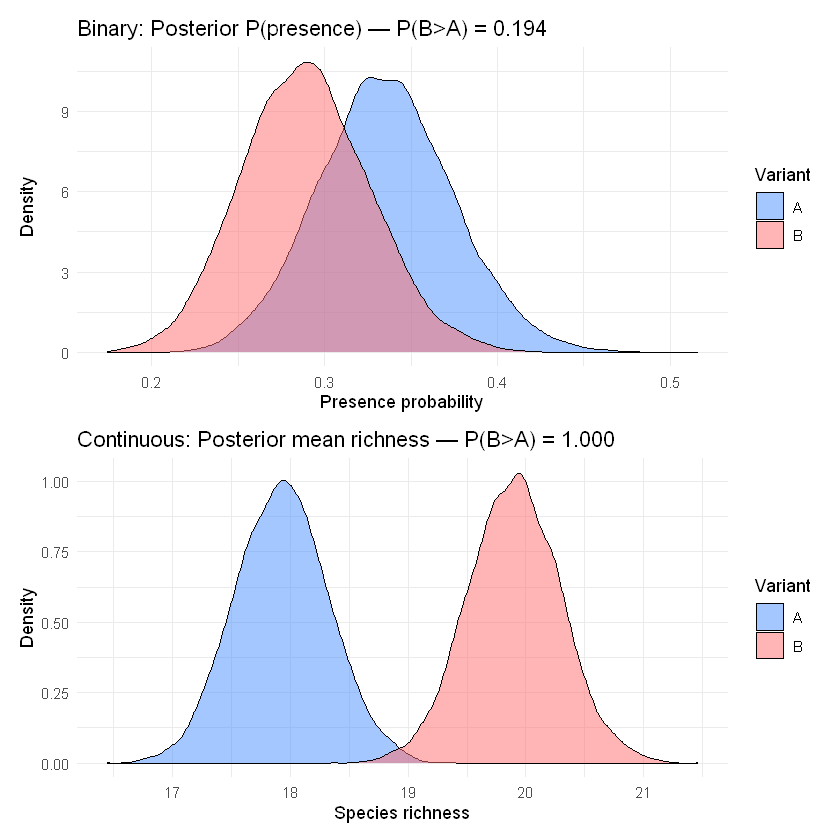

In [7]:
library(tidyverse)
library(ggplot2)
library(patchwork)

set.seed(42)

# ── Scenario A: binary outcome (species presence) ─────────────────────────────
n_A <- 150; n_B <- 150
p_A_true <- 0.28; p_B_true <- 0.38

obs_A_binary <- rbinom(n_A, 1, p_A_true)
obs_B_binary <- rbinom(n_B, 1, p_B_true)

# ── Scenario B: continuous outcome (species richness) ────────────────────────
obs_A_cont <- rnorm(n_A, mean = 18, sd = 5)
obs_B_cont <- rnorm(n_B, mean = 20, sd = 5.2)

cat(sprintf("Binary: A=%.3f, B=%.3f | Continuous: A=%.2f, B=%.2f\n",
            mean(obs_A_binary), mean(obs_B_binary),
            mean(obs_A_cont),   mean(obs_B_cont)))

# ── Binary: Beta-Binomial conjugate model ─────────────────────────────────────
# Prior: Beta(1, 1) = uniform
# Posterior: Beta(1 + successes, 1 + failures)
alpha_prior <- 1; beta_prior <- 1

post_A_alpha <- alpha_prior + sum(obs_A_binary)
post_A_beta  <- beta_prior  + (n_A - sum(obs_A_binary))
post_B_alpha <- alpha_prior + sum(obs_B_binary)
post_B_beta  <- beta_prior  + (n_B - sum(obs_B_binary))

# Monte Carlo estimate of P(B > A)
n_samples <- 100000
samples_A <- rbeta(n_samples, post_A_alpha, post_A_beta)
samples_B <- rbeta(n_samples, post_B_alpha, post_B_beta)
prob_B_gt_A <- mean(samples_B > samples_A)

cat(sprintf("\nBinary A/B:\n"))
cat(sprintf("  Posterior A: Beta(%.0f, %.0f) → mean = %.3f\n",
            post_A_alpha, post_A_beta, post_A_alpha / (post_A_alpha + post_A_beta)))
cat(sprintf("  Posterior B: Beta(%.0f, %.0f) → mean = %.3f\n",
            post_B_alpha, post_B_beta, post_B_alpha / (post_B_alpha + post_B_beta)))
cat(sprintf("  P(B > A) = %.3f\n", prob_B_gt_A))

# ── Continuous: Normal model with known variance (approximation) ──────────────
# Use posterior predictive sampling — normal-normal conjugate
n_samples_cont <- 100000
# Posterior mean ≈ sample mean (with diffuse prior)
# Posterior SD approximated by SE of the mean
post_mean_A <- mean(obs_A_cont); post_sd_A <- sd(obs_A_cont) / sqrt(n_A)
post_mean_B <- mean(obs_B_cont); post_sd_B <- sd(obs_B_cont) / sqrt(n_B)

samples_A_cont <- rnorm(n_samples_cont, post_mean_A, post_sd_A)
samples_B_cont <- rnorm(n_samples_cont, post_mean_B, post_sd_B)
prob_B_gt_A_cont <- mean(samples_B_cont > samples_A_cont)

cat(sprintf("\nContinuous A/B:\n"))
cat(sprintf("  Posterior A: mean = %.2f, sd = %.3f\n", post_mean_A, post_sd_A))
cat(sprintf("  Posterior B: mean = %.2f, sd = %.3f\n", post_mean_B, post_sd_B))
cat(sprintf("  P(B > A) = %.3f\n", prob_B_gt_A_cont))

# ── Plot posterior distributions ──────────────────────────────────────────────
p_binary <- tibble(
  x        = c(samples_A[1:10000], samples_B[1:10000]),
  variant  = rep(c("A", "B"), each = 10000)
) %>%
  ggplot(aes(x = x, fill = variant)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c(A = "#4a8fff", B = "#ff6b6b")) +
  labs(title    = sprintf("Binary: Posterior P(presence) — P(B>A) = %.3f", prob_B_gt_A),
       x = "Presence probability", y = "Density", fill = "Variant") +
  theme_minimal()

p_cont <- tibble(
  x       = c(samples_A_cont[1:10000], samples_B_cont[1:10000]),
  variant = rep(c("A", "B"), each = 10000)
) %>%
  ggplot(aes(x = x, fill = variant)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c(A = "#4a8fff", B = "#ff6b6b")) +
  labs(title    = sprintf("Continuous: Posterior mean richness — P(B>A) = %.3f", prob_B_gt_A_cont),
       x = "Species richness", y = "Density", fill = "Variant") +
  theme_minimal()

(p_binary / p_cont)

---

## Binary Outcome: Beta-Binomial Model

Posterior A: Beta(53, 107) → mean = 0.331
Posterior B: Beta(46, 114) → mean = 0.287

P(B > A): 0.1951 (19.5%)
Expected loss (choosing A): 0.0056
→ Interpretable: expected regret from a wrong decision

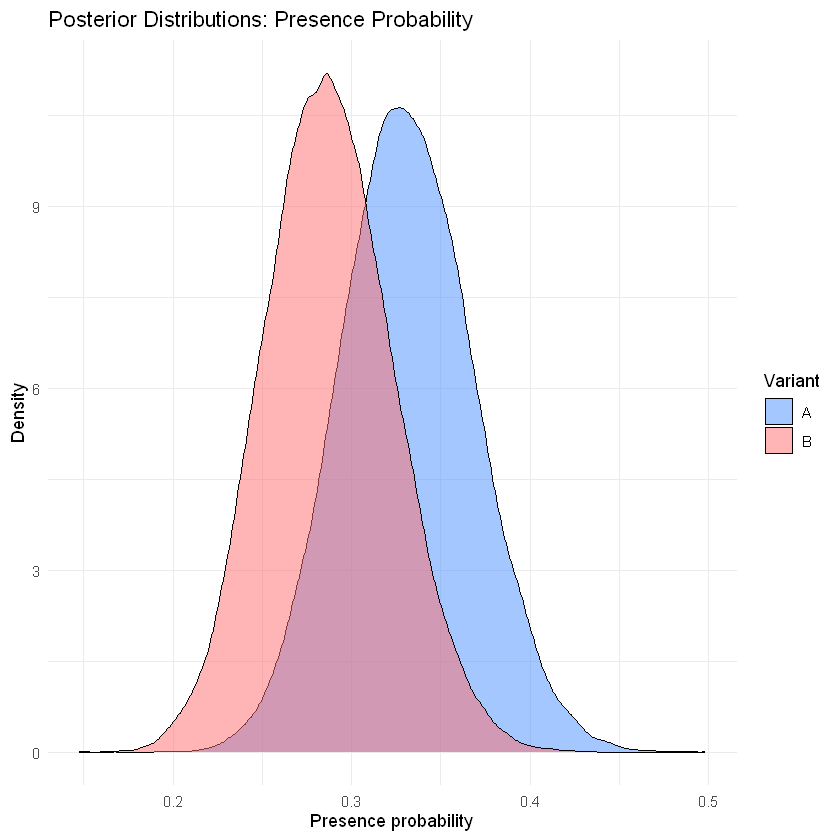

In [9]:
# Beta prior for conversion/presence rate
# Beta(1,1) = uniform (no prior knowledge)
# Beta(3,7) = weakly informative prior centred at 30%
# Posterior: Beta(alpha + successes, beta + failures)

# ── Fit Bayesian test (base R Beta-Binomial conjugate) ────────────────────────
alpha_prior <- 3; beta_prior <- 7   # Beta(3,7): prior belief ≈ 30% baseline

post_A_alpha <- alpha_prior + sum(obs_A_binary)
post_A_beta  <- beta_prior  + (n_A - sum(obs_A_binary))
post_B_alpha <- alpha_prior + sum(obs_B_binary)
post_B_beta  <- beta_prior  + (n_B - sum(obs_B_binary))

n_samples <- 1e5
samples_A <- rbeta(n_samples, post_A_alpha, post_A_beta)
samples_B <- rbeta(n_samples, post_B_alpha, post_B_beta)

cat(sprintf("Posterior A: Beta(%.0f, %.0f) → mean = %.3f\n",
            post_A_alpha, post_A_beta,
            post_A_alpha / (post_A_alpha + post_A_beta)))
cat(sprintf("Posterior B: Beta(%.0f, %.0f) → mean = %.3f\n",
            post_B_alpha, post_B_beta,
            post_B_alpha / (post_B_alpha + post_B_beta)))

# ── Posterior distributions ───────────────────────────────────────────────────
post_df <- tibble(
  x       = c(samples_A, samples_B),
  variant = rep(c("A", "B"), each = n_samples)
)

ggplot(post_df, aes(x = x, fill = variant)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c(A = "#4a8fff", B = "#ff6b6b")) +
  labs(title = "Posterior Distributions: Presence Probability",
       x = "Presence probability", y = "Density", fill = "Variant") +
  theme_minimal()

# ── Probability B > A and expected loss ──────────────────────────────────────
p_b_better <- mean(samples_B > samples_A)
cat(sprintf("\nP(B > A): %.4f (%.1f%%)\n", p_b_better, p_b_better * 100))

# Expected loss from choosing A when B is actually better
loss_choose_A <- mean(pmax(0, samples_B - samples_A))
cat(sprintf("Expected loss (choosing A): %.4f\n", loss_choose_A))
cat("→ Interpretable: expected regret from a wrong decision")

---

## Continuous Outcome: Normal-Normal Model

Posterior mean A: 17.927
Posterior mean B: 19.895


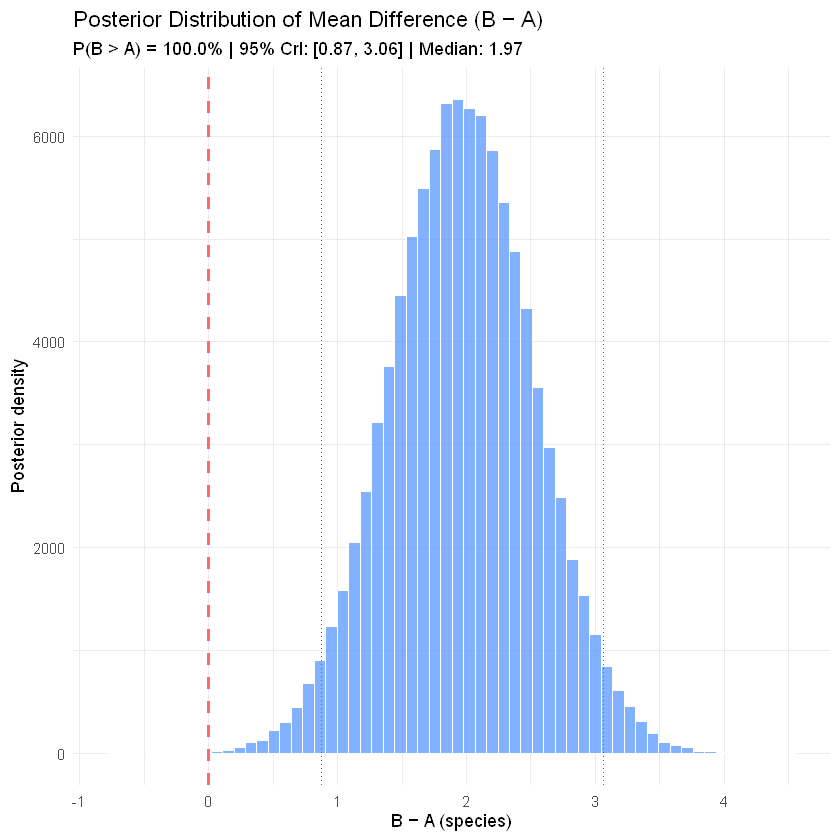

In [11]:
# Normal-Inverse-Gamma conjugate update (replaces bayesAB::bayesTest normal)
# Prior hyperparameters
mu_0    <- 18   # prior mean
kappa_0 <- 1    # prior confidence in mean
alpha_0 <- 3    # prior on variance shape
beta_0  <- 75   # prior on variance scale (beta_0/alpha_0 ≈ 25 = prior variance)

# ── Posterior update for each group ──────────────────────────────────────────
nig_posterior <- function(obs, mu_0, kappa_0, alpha_0, beta_0) {
  n       <- length(obs)
  xbar    <- mean(obs)
  kappa_n <- kappa_0 + n
  mu_n    <- (kappa_0 * mu_0 + n * xbar) / kappa_n
  alpha_n <- alpha_0 + n / 2
  beta_n  <- beta_0 + 0.5 * sum((obs - xbar)^2) +
             (kappa_0 * n * (xbar - mu_0)^2) / (2 * kappa_n)
  list(mu_n = mu_n, kappa_n = kappa_n, alpha_n = alpha_n, beta_n = beta_n)
}

post_A <- nig_posterior(obs_A_cont, mu_0, kappa_0, alpha_0, beta_0)
post_B <- nig_posterior(obs_B_cont, mu_0, kappa_0, alpha_0, beta_0)

# ── Sample from posterior: first sample variance, then mean | variance ────────
n_samples <- 1e5

sample_nig_mean <- function(post, n) {
  sigma2 <- 1 / rgamma(n, shape = post$alpha_n, rate = post$beta_n)
  rnorm(n, mean = post$mu_n, sd = sqrt(sigma2 / post$kappa_n))
}

samples_A_mu <- sample_nig_mean(post_A, n_samples)
samples_B_mu <- sample_nig_mean(post_B, n_samples)

cat(sprintf("Posterior mean A: %.3f\n", mean(samples_A_mu)))
cat(sprintf("Posterior mean B: %.3f\n", mean(samples_B_mu)))

# ── Visualise posterior on mean difference ────────────────────────────────────
post_diff <- samples_B_mu - samples_A_mu

ggplot(tibble(diff = post_diff), aes(x = diff)) +
  geom_histogram(bins = 60, fill = "#4a8fff", alpha = 0.7, color = "white") +
  geom_vline(xintercept = 0, linetype = "dashed",
             color = "#ff6b6b", linewidth = 1) +
  geom_vline(xintercept = quantile(post_diff, c(0.025, 0.975)),
             linetype = "dotted", color = "gray40") +
  labs(
    title    = "Posterior Distribution of Mean Difference (B − A)",
    subtitle = sprintf("P(B > A) = %.1f%% | 95%% CrI: [%.2f, %.2f] | Median: %.2f",
                       mean(post_diff > 0) * 100,
                       quantile(post_diff, 0.025),
                       quantile(post_diff, 0.975),
                       median(post_diff)),
    x = "B − A (species)", y = "Posterior density"
  ) +
  theme_minimal()

---

## Prior Sensitivity Analysis

In [12]:
# Results should be robust to reasonable prior choices
# If conclusions change dramatically with the prior, the data are insufficient

priors_to_test <- list(
  flat     = c(alpha = 1,  beta = 1),    # uniform
  weak     = c(alpha = 3,  beta = 7),    # centred at 30%
  informed = c(alpha = 6,  beta = 14),   # stronger belief at 30%
  wrong    = c(alpha = 10, beta = 10)    # prior at 50% (misspecified)
)

prior_results <- map_dfr(names(priors_to_test), function(nm) {
  pr <- priors_to_test[[nm]]

  # Beta-Binomial conjugate update
  post_A_alpha <- pr["alpha"] + sum(obs_A_binary)
  post_A_beta  <- pr["beta"]  + (n_A - sum(obs_A_binary))
  post_B_alpha <- pr["alpha"] + sum(obs_B_binary)
  post_B_beta  <- pr["beta"]  + (n_B - sum(obs_B_binary))

  samples_A <- rbeta(5e4, post_A_alpha, post_A_beta)
  samples_B <- rbeta(5e4, post_B_alpha, post_B_beta)

  tibble(
    prior       = nm,
    prior_mean  = pr["alpha"] / (pr["alpha"] + pr["beta"]),
    P_B_gt_A    = round(mean(samples_B > samples_A), 4),
    post_A_mean = round(mean(samples_A), 4),
    post_B_mean = round(mean(samples_B), 4)
  )
})

print(prior_results)
# If P(B>A) is similar across priors: data dominate; conclusions are robust
# If P(B>A) varies widely: data are weak; prior specification matters critically

# A tibble: 4 × 5
  prior    prior_mean P_B_gt_A post_A_mean post_B_mean
  <chr>         <dbl>    <dbl>       <dbl>       <dbl>
1 flat            0.5    0.193       0.336       0.289
2 weak            0.3    0.196       0.331       0.287
3 informed        0.3    0.202       0.33        0.288
4 wrong           0.5    0.208       0.353       0.312


---

## Common Pitfalls

**1. Choosing a prior after seeing the data**  
The prior must be specified before examining the data — it represents prior knowledge, not a tuning parameter to be adjusted until results look favourable. Trying multiple priors and reporting the one that gives the most appealing P(B > A) is equivalent to p-hacking. Pre-specify the prior and conduct a sensitivity analysis across a range of defensible alternatives.

**2. Using P(B > A) as a decision threshold without considering expected loss**  
P(B > A) = 0.95 sounds decisive, but the posterior distribution of the difference might be concentrated near zero — a high probability of a negligible effect. Expected loss integrates both the probability and the magnitude of being wrong. A P(B > A) = 0.85 with a large potential gain may be a better decision than P(B > A) = 0.97 with a tiny gain.

**3. Claiming that Bayesian testing allows unlimited peeking**  
Some Bayesian frameworks (e.g. mSPRT, always-valid inference) do allow continuous monitoring with proper error control. Standard Bayesian A/B testing with fixed priors does not — repeatedly checking the posterior and stopping when P(B > A) > 0.95 inflates error just as frequentist peeking does. Use a properly calibrated sequential Bayesian design if early stopping is needed.

**4. Interpreting the credible interval as a confidence interval**  
A 95% Bayesian credible interval [a, b] means: given the prior and data, there is a 95% posterior probability that the true parameter lies in [a, b]. This IS the intuitive interpretation most people incorrectly apply to frequentist CIs. They are philosophically different constructs — but the practical distinction matters mainly when priors are informative.

**5. Using flat priors and calling the analysis "objective"**  
A flat (uniform) prior is not objective — it still encodes assumptions (e.g. that a 1% conversion rate is as plausible as a 99% rate). For proportion testing, a weakly informative prior centred near the historical baseline is almost always more appropriate than a flat prior. Report the prior and its justification alongside results.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*